# Region Field Heatmaps

For a given `motionmapperpy` project (UMAP embedding + watershed segmentation, e.g.
`Results/LargeBlindVisualActivity/`), this notebook computes the **mean value** of
several sensor fields &mdash; CO&#8322; (averaged over the two sensor channels),
relative humidity, activity and ambient temperature &mdash; over every watershed
region, and renders each as a heatmap painted directly onto the region map (the
same regions shown in `UMAP/zWshed*.png`, e.g. `zWshed15.png` for a 15-region run).

**Prerequisite:** the target project must already have gone through the watershed
step of `Ethogram_Generation_Metabolism.ipynb` (i.e. `UMAP/zVals_wShed_groups.mat`
must exist), and the per-dataset raw dataframes must be cached in
`Results/Intermediate_Results/*.pkl` (produced by the same notebook's dataset-loading
section). This notebook does not re-download any data or re-run PCA/UMAP/watershed
&mdash; it only reloads what that pipeline already computed and saved.

Uses the same region-alignment logic as `Ethogram_Generation_Metabolism.ipynb`
(see its "Region Timeline" section) and the watershed-artifact loader from
`umap_video_utils.py`.

Kernel: `motionmapper37` (same as `Ethogram_Generation_Metabolism.ipynb`).

## 1.&nbsp; Imports

In [1]:
import glob, os, pickle, re, sys
from pathlib import Path

sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots/RHCImaging')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation/RHCThermalPlots')
sys.path.append('Metabolism/VisualActivity/RHCVisualisation')
sys.path.append('Metabolism/VisualActivity')
sys.path.append('Metabolism')
sys.path.insert(0, os.path.abspath('motionmapperpy-master'))

import hdf5storage
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from umap_video_utils import load_watershed_artifacts

%matplotlib inline

## 2.&nbsp; Configuration

In [2]:
# Path to the motionmapperpy project directory (same one used in Ethogram_Generation_Metabolism.ipynb)
projectPath = r"/Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity/"
intermediate_dir = "Results/Intermediate_Results"

PROJECT_DIR = Path(projectPath)
PROJECTIONS_DIR = PROJECT_DIR / "Projections"

# parameters.pkl records which method (UMAP/TSNE) and project path were used to build the
# watershed run, so we load it instead of hard-coding the method.
with open(PROJECT_DIR / "parameters.pkl", "rb") as f:
    parameters = pickle.load(f)

UMAP_DIR = PROJECT_DIR / parameters.method
WSHED_PATH = UMAP_DIR / "zVals_wShed_groups.mat"
assert WSHED_PATH.exists(), f"Watershed file not found at {WSHED_PATH}. Run the watershed step of Ethogram_Generation_Metabolism.ipynb first."
print(f"Project: {PROJECT_DIR}")
print(f"Method : {parameters.method}")
print(f"Watershed file: {WSHED_PATH}")

Project: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity
Method : UMAP
Watershed file: /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity/UMAP/zVals_wShed_groups.mat


## 3.&nbsp; Load per-dataset raw data

Dataset identity (`{exp}_hive{hive_nb}_{ihl}`) is taken directly from the
`*_pcaModes.mat` files present in `Projections/`, i.e. exactly the datasets that
went into the current watershed run &mdash; not from the experiment config, so this
stays correct even if `used_exp_list` changes in the source notebook.

In [3]:
dataset_id_pattern = re.compile(r"^(?P<exp>.+)_hive(?P<hive>\d+)_(?P<ihl>upper|lower)$")

dataset_keys = []  # list of (exp, hive_nb, ihl)
for pca_file in sorted(PROJECTIONS_DIR.glob("*_pcaModes.mat")):
    source_id = pca_file.name[: -len("_pcaModes.mat")]
    m = dataset_id_pattern.match(source_id)
    if not m:
        print(f"Skipping unrecognized projection file name: {pca_file.name}")
        continue
    dataset_keys.append((m.group("exp"), int(m.group("hive")), m.group("ihl")))

print(f"Found {len(dataset_keys)} datasets in {PROJECTIONS_DIR}:")
for key in dataset_keys:
    print(" ", key)

Found 14 datasets in /Users/cyrilmonette/Desktop/EPFL 2018-2026/PhD - Mobots/PdS/(25b) Ethograms/Ethogram-Generation/Results/LargeBlindVisualActivity/Projections:
  ('Constant', 2, 'upper')
  ('Idle', 1, 'upper')
  ('Idle', 2, 'upper')
  ('Observation', 1, 'lower')
  ('Observation', 1, 'upper')
  ('Observation', 2, 'lower')
  ('Observation', 2, 'upper')
  ('SharpDay', 1, 'upper')
  ('SharpDay', 2, 'upper')
  ('SharpNight', 1, 'upper')
  ('SharpNight', 2, 'upper')
  ('SoftDay', 1, 'upper')
  ('SoftDay', 2, 'upper')
  ('SoftNight', 1, 'upper')


In [4]:
exps_dfs = {}
for key in dataset_keys:
    exp, hive_nb, ihl = key
    source_id = f"{exp}_hive{hive_nb}_{ihl}"
    pkl_path = os.path.join(intermediate_dir, f"{source_id}.pkl")
    assert os.path.exists(pkl_path), (
        f"Missing cached dataset {pkl_path}. Run the dataset-loading section of "
        f"Ethogram_Generation_Metabolism.ipynb (with save_files=True) first."
    )
    with open(pkl_path, "rb") as f:
        exps_dfs[key] = pickle.load(f)
    print(f"Loaded {source_id}: {exps_dfs[key].shape}")

Loaded Constant_hive2_upper: (419, 5)
Loaded Idle_hive1_upper: (1475, 5)
Loaded Idle_hive2_upper: (1351, 5)
Loaded Observation_hive1_lower: (7227, 5)
Loaded Observation_hive1_upper: (7232, 5)
Loaded Observation_hive2_lower: (3491, 5)
Loaded Observation_hive2_upper: (3391, 5)
Loaded SharpDay_hive1_upper: (1526, 5)
Loaded SharpDay_hive2_upper: (1233, 5)
Loaded SharpNight_hive1_upper: (1988, 5)
Loaded SharpNight_hive2_upper: (981, 5)
Loaded SoftDay_hive1_upper: (1871, 5)
Loaded SoftDay_hive2_upper: (1433, 5)
Loaded SoftNight_hive1_upper: (2193, 5)


## 4.&nbsp; Reproduce the interpolation/dropna step

Same as the "Preprocessing of Data" section of `Ethogram_Generation_Metabolism.ipynb`:
linearly interpolate short NaN gaps (limit=6 samples) then drop any rows that are
still incomplete. This must match exactly, since it determines which rows were fed
into PCA/UMAP and therefore which rows the watershed regions were computed for.

In [5]:
exps_dfs_dropna = {}
for key, df in exps_dfs.items():
    df = df.astype(float)
    df = df.interpolate(method='time', limit=6, limit_direction='both')
    df = df.dropna(how='any')
    exps_dfs_dropna[key] = df
    print(f"{key}: {len(df)} rows remaining after interpolation/dropna")

('Constant', 2, 'upper'): 419 rows remaining after interpolation/dropna
('Idle', 1, 'upper'): 1475 rows remaining after interpolation/dropna
('Idle', 2, 'upper'): 1351 rows remaining after interpolation/dropna
('Observation', 1, 'lower'): 4207 rows remaining after interpolation/dropna
('Observation', 1, 'upper'): 4505 rows remaining after interpolation/dropna
('Observation', 2, 'lower'): 2003 rows remaining after interpolation/dropna
('Observation', 2, 'upper'): 2003 rows remaining after interpolation/dropna
('SharpDay', 1, 'upper'): 1526 rows remaining after interpolation/dropna
('SharpDay', 2, 'upper'): 1233 rows remaining after interpolation/dropna
('SharpNight', 1, 'upper'): 1988 rows remaining after interpolation/dropna
('SharpNight', 2, 'upper'): 981 rows remaining after interpolation/dropna
('SoftDay', 1, 'upper'): 1868 rows remaining after interpolation/dropna
('SoftDay', 2, 'upper'): 1433 rows remaining after interpolation/dropna
('SoftNight', 1, 'upper'): 2174 rows remaining 

In [6]:
# full_dts: the full timestamp range for each dataset (used only to build df_nat below)
full_dts = {}
for key, df in exps_dfs_dropna.items():
    full_dts[key] = pd.date_range(df.index.min(), df.index.max(), freq='10min')

## 5.&nbsp; Build the per-point dataframe (`df_nat`)

One row per kept timepoint, tagged with its `source_id` and real timestamp &mdash;
mirrors `df_nat` in `Ethogram_Generation_Metabolism.ipynb`.

In [7]:
df_nat = []
for key, df in exps_dfs_dropna.items():
    df = df.copy()
    df["real_timestamp"] = df.index
    df["source_id"] = f"{key[0]}_hive{key[1]}_{key[2]}"
    df_nat.append(df)

df_nat = pd.concat(df_nat, axis=0).sort_index()
print(df_nat.shape)
df_nat.tail()

(27166, 7)


,Tamb,co2_L,co2_R,rel_humid,activity,real_timestamp,source_id
datetime,,,,,,,
2025-01-19 15:20:00+00:00,13.114583,3251.0,1005.0,46.035617,0.097607,2025-01-19 15:20:00+00:00,SoftDay_hive1_upper
2025-01-19 15:30:00+00:00,13.132812,3583.0,1275.0,46.165240,0.098448,2025-01-19 15:30:00+00:00,SoftDay_hive1_upper
2025-01-19 15:40:00+00:00,13.140625,3964.0,1560.0,46.229563,0.103370,2025-01-19 15:40:00+00:00,SoftDay_hive1_upper
2025-01-19 15:50:00+00:00,13.138021,3902.0,1368.0,46.277503,0.101393,2025-01-19 15:50:00+00:00,SoftDay_hive1_upper
2025-01-19 16:00:00+00:00,12.958333,3722.0,1371.0,47.041890,0.101393,2025-01-19 16:00:00+00:00,SoftDay_hive1_upper


## 6.&nbsp; Load the watershed artifacts

`load_watershed_artifacts` (from `umap_video_utils.py`) loads `density`/`xx`/`wbounds`
and normalizes the region-boundary polygons; we additionally pull out `LL`, the 2D
region-label image (same grid, unrandomized colors) that isn't exposed by that helper,
plus `zValNames`/`zValLens` needed for the per-dataset region alignment below.

15 regions found in zVals_wShed_groups.mat: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15]


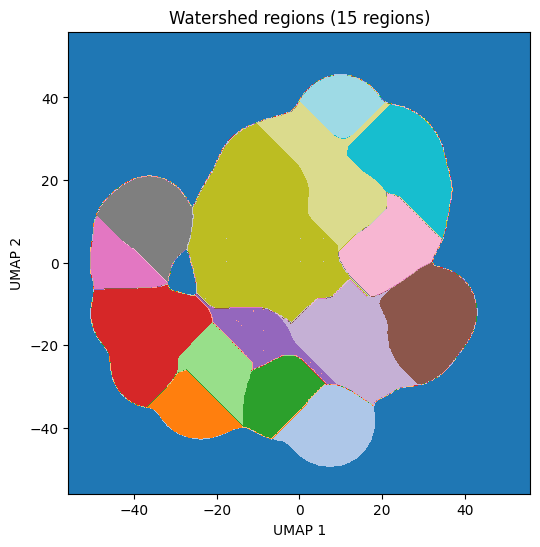

In [8]:
artifacts = load_watershed_artifacts(str(WSHED_PATH))
wshed_raw = hdf5storage.loadmat(str(WSHED_PATH))

LL = np.asarray(wshed_raw["LL"])
xx = artifacts["xx"].squeeze()
extent = artifacts["extent"]
wbounds = artifacts["wbounds"]

region_ids = sorted(int(r) for r in np.unique(LL) if r > 0)
print(f"{len(region_ids)} regions found in {WSHED_PATH.name}: {region_ids}")

fig, ax = plt.subplots(figsize=(6, 6))
ax.imshow(LL, origin='lower', extent=extent, cmap='tab20')
ax.set_title(f"Watershed regions ({len(region_ids)} regions)")
ax.set_xlabel("UMAP 1")
ax.set_ylabel("UMAP 2")
plt.show()

## 7.&nbsp; Assign each row of `df_nat` to a region

Same alignment logic as the "Region Timeline" section of
`Ethogram_Generation_Metabolism.ipynb`: `mmpy.findWatershedRegions` concatenates every
dataset's embeddings in whatever order `glob.glob` returned them (filesystem-dependent,
**not** alphabetical), but the true per-dataset order and block lengths are recorded in
the watershed file itself as `zValNames`/`zValLens`. We use those to slice out each
dataset's own `watershedRegions` block, then match rows by real timestamp (via each
dataset's `outputStatistics.keptIdx`, which records which timestamps survived
wavelet/UMAP preprocessing).

In [9]:
watershedRegions_full = wshed_raw["watershedRegions"].flatten().astype(float)
zval_names = [str(np.asarray(n).ravel()[0]) for n in wshed_raw["zValNames"].flatten()]
zval_lens = wshed_raw["zValLens"].flatten().astype(int)
zval_offsets = np.cumsum([0] + zval_lens[:-1].tolist())

source_id_blocks = {}
for name, length, offset in zip(zval_names, zval_lens, zval_offsets):
    stem = name[: -len("_pcaModes")] if name.endswith("_pcaModes") else name
    source_id_blocks[stem] = (offset, length)

df_nat["region"] = np.nan

for key in dataset_keys:
    source_id = f"{key[0]}_hive{key[1]}_{key[2]}"
    stats_file = PROJECTIONS_DIR / f"{source_id}_pcaModes_uVals_outputStatistics.pkl"
    pca_file = PROJECTIONS_DIR / f"{source_id}_pcaModes.mat"

    with open(stats_file, "rb") as hfile:
        outputStatistics = pickle.load(hfile)
    pca_data = hdf5storage.loadmat(str(pca_file))

    keptIdx = np.asarray(outputStatistics.keptIdx).astype(int).ravel()
    real_ts = pd.to_datetime(np.asarray(pca_data["real_timestamps"]).squeeze(), utc=True)
    real_ts = real_ts[keptIdx]

    offset, length = source_id_blocks[source_id]
    assert length == len(keptIdx), (
        f"keptIdx length ({len(keptIdx)}) doesn't match the watershed block length ({length}) "
        f"for {source_id}; the wshed file may be stale relative to the Projections folder."
    )
    region_classification = watershedRegions_full[offset : offset + length]

    ts_to_region = dict(zip(real_ts, region_classification))
    mask_source = df_nat["source_id"] == source_id
    df_nat.loc[mask_source, "region"] = df_nat.loc[mask_source, "real_timestamp"].map(ts_to_region)

n_before = len(df_nat)
df_nat = df_nat.dropna(subset=["region"])
df_nat["region"] = df_nat["region"].astype(int)
print(f"Assigned a region to {len(df_nat)}/{n_before} rows.")
assert len(df_nat) == len(watershedRegions_full), (
    f"df_nat ({len(df_nat)}) and the watershed's point count ({len(watershedRegions_full)}) "
    "should match exactly -- every embedded point should map back to exactly one row."
)

Assigned a region to 22886/27166 rows.


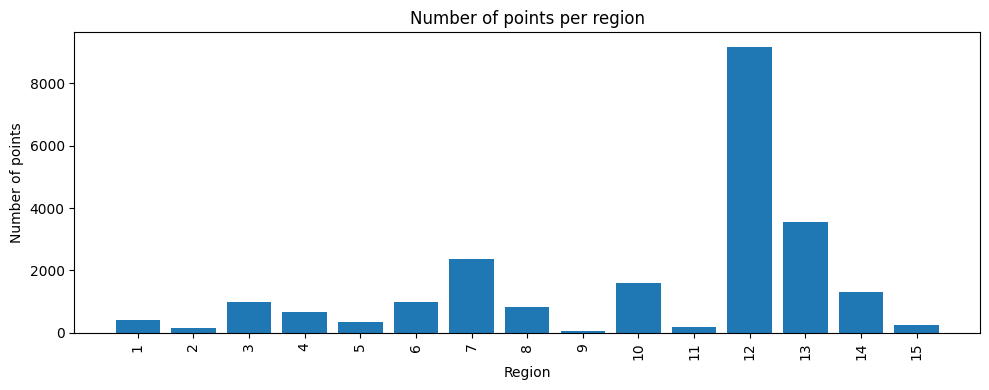

In [10]:
# Sanity check: number of points per region should match the watershed file's own counts
counts = df_nat["region"].value_counts().sort_index()
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(counts.index, counts.values)
ax.set_xlabel("Region")
ax.set_ylabel("Number of points")
ax.set_title("Number of points per region")
ax.set_xticks(counts.index)
ax.tick_params(axis="x", rotation=90)
plt.tight_layout()
plt.show()

## 8.&nbsp; Compute per-region means

Mean CO&#8322; is the average of the two sensor channels (`co2_L`, `co2_R`); activity
is stored as a 0-1 fraction and converted to a percentage; relative humidity and
ambient temperature are used as-is.

In [11]:
df_nat["co2_mean"] = df_nat[["co2_L", "co2_R"]].mean(axis=1)
df_nat["activity_pct"] = df_nat["activity"] * 100.0

FIELDS = {
    "Mean CO2 (ppm)": ("co2_mean", "viridis"),
    "Relative humidity (%)": ("rel_humid", "viridis"),
    "Activity (%)": ("activity_pct", "viridis"),
    "Ambient temperature (C)": ("Tamb", "viridis"),
}

region_means = {
    title: df_nat.groupby("region")[col].mean()
    for title, (col, _cmap) in FIELDS.items()
}

for title, means in region_means.items():
    print(f"\n{title}:")
    print(means)


Mean CO2 (ppm):
region
1     2304.378079
2     2533.703030
3     1231.649590
4     2963.966317
5     2773.481793
6     2731.619243
7     1833.332003
8     1106.484830
9     6130.337662
10    3216.884615
11    5612.127119
12    6351.394544
13    5996.926066
14    4323.931679
15    1982.864583
Name: co2_mean, dtype: float64

Relative humidity (%):
region
1     60.459223
2     43.456823
3     48.747250
4     51.791889
5     60.049331
6     50.419315
7     50.108847
8     41.625054
9     75.440041
10    53.228921
11    70.079458
12    56.598991
13    56.620654
14    51.355907
15    50.398058
Name: rel_humid, dtype: float64

Activity (%):
region
1     11.589563
2      4.920132
3      8.876844
4     14.111728
5     18.922013
6     13.899131
7     13.898120
8      5.584405
9     17.270060
10    19.942696
11    13.931984
12    15.036612
13    18.002825
14    11.140345
15     8.189176
Name: activity_pct, dtype: float64

Ambient temperature (C):
region
1     11.007075
2     14.958191
3     14.0

## 9.&nbsp; Heatmaps over the watershed regions

Each region is filled with its mean value for the given field (regions with no
assigned points are left blank), region boundaries are traced in black, and region
numbers are annotated at each region's centroid &mdash; the same numbering as in
`UMAP/zWshed15.png`.

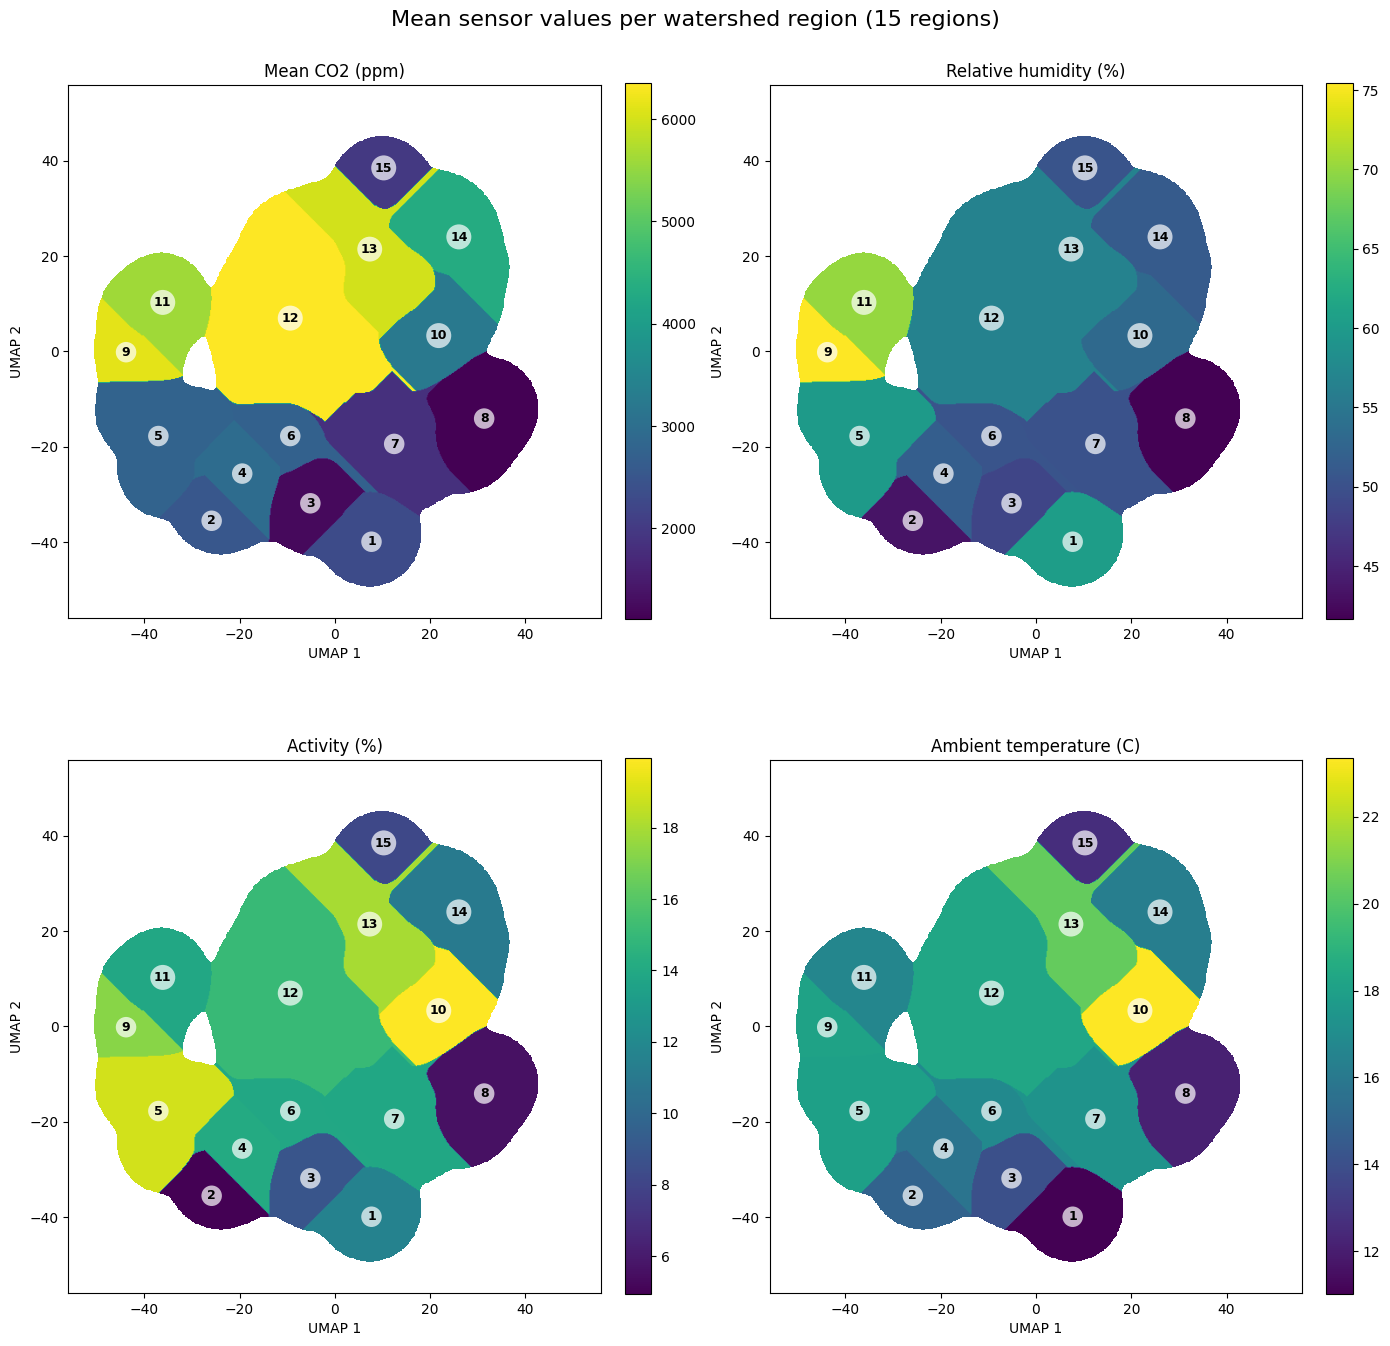

In [12]:
def region_value_map(LL, means):
    """Paint each pixel of the label image LL with its region's mean value (NaN elsewhere)."""
    H = np.full(LL.shape, np.nan)
    for region_id, value in means.items():
        H[LL == region_id] = value
    return H


def plot_region_heatmap(ax, LL, means, xx, wbounds, title, cmap):
    extent = (xx.min(), xx.max(), xx.min(), xx.max())
    H = region_value_map(LL, means)

    im = ax.imshow(H, origin="lower", extent=extent, cmap=cmap, aspect="equal")

    for boundary in wbounds:
        boundary = np.asarray(boundary, dtype=float)
        if boundary.ndim == 2 and boundary.shape[1] == 2:
            ax.plot(boundary[:, 0], boundary[:, 1], color="black", linewidth=0.6, alpha=0.6)

    for region_id in means.index:
        ys, xs = np.where(LL == region_id)
        if xs.size == 0:
            continue
        cx = xx[int(round(xs.mean()))]
        cy = xx[int(round(ys.mean()))]
        ax.text(
            cx, cy, str(int(region_id)),
            ha="center", va="center", fontsize=9, fontweight="bold", color="black",
            bbox=dict(boxstyle="circle", fc="white", alpha=0.7, ec="none"),
        )

    ax.set_title(title)
    ax.set_xlabel("UMAP 1")
    ax.set_ylabel("UMAP 2")
    fig = ax.get_figure()
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return im


fig, axes = plt.subplots(2, 2, figsize=(14, 14))
for ax, (title, (col, cmap)) in zip(axes.flat, FIELDS.items()):
    plot_region_heatmap(ax, LL, region_means[title], xx, wbounds, title, cmap)

fig.suptitle(f"Mean sensor values per watershed region ({len(region_ids)} regions)", fontsize=16)
plt.tight_layout()
plt.show()

## 10.&nbsp; Most meaningful timeframe per region (from wavelet coefficients)

`findEmbeddings(..., saveWaveletAmps=True)` (see `motionmapperpy/motionmapper.py`) now
saves each dataset's Morlet wavelet amplitude spectrum &mdash; one amplitude-vs-period
curve per PCA mode, per kept timepoint &mdash; into its own
`Projections/{source_id}_pcaModes_uVals_outputStatistics.pkl`, alongside the period
axis (`waveletFrequencies`, log-spaced between `parameters.minF` and `parameters.maxF`).
Reusing `_load_wavelet_data`/`_characteristic_period_minutes` from `umap_interp_utils.py`
(already used there to size a raw-data window around a clicked UMAP point from its own
wavelet spectrum), we aggregate these *per point* spectra into one average spectrum
*per region*, then take that spectrum's amplitude-weighted mean period as the region's
characteristic ("most meaningful") timescale.

A dataset's wavelet amplitude rows share the exact same order as its watershed-region
block (both are computed downstream of the same per-dataset, order-preserving
wavelet &rarr; UMAP-embed &rarr; watershed-assign steps), so no timestamp matching is
needed here &mdash; row *j* of `waveletAmplitudes` is row *j* of that dataset's region
block.

In [13]:
from umap_interp_utils import _load_wavelet_data, _characteristic_period_minutes

sum_spectrum = {}    # region_id -> running sum of mode-summed amplitude spectra
count_spectrum = {}  # region_id -> number of points contributing
wavelet_frequencies = None
missing_wavelets = []

for key in dataset_keys:
    source_id = f"{key[0]}_hive{key[1]}_{key[2]}"
    amps, freqs = _load_wavelet_data(source_id, PROJECTIONS_DIR)
    if amps is None:
        missing_wavelets.append(source_id)
        continue

    if wavelet_frequencies is None:
        wavelet_frequencies = freqs
    num_periods = freqs.shape[0]

    offset, length = source_id_blocks[source_id]
    assert amps.shape[0] == length, (
        f"waveletAmplitudes row count ({amps.shape[0]}) doesn't match the watershed block "
        f"length ({length}) for {source_id}; the wshed file may be stale relative to the "
        f"Projections folder."
    )
    region_classification = watershedRegions_full[offset : offset + length].astype(int)
    mode_summed = amps.reshape(length, -1, num_periods).sum(axis=1)  # (length, numPeriods)

    for rid in np.unique(region_classification):
        if rid <= 0:
            continue
        mask = region_classification == rid
        sum_spectrum[rid] = sum_spectrum.get(rid, 0.0) + mode_summed[mask].sum(axis=0)
        count_spectrum[rid] = count_spectrum.get(rid, 0) + int(mask.sum())

if missing_wavelets:
    print(
        f"No saved waveletAmplitudes for: {missing_wavelets} (skipped -- re-run "
        f"findEmbeddings(..., saveWaveletAmps=True) for these datasets to include them)"
    )

average_spectrum = {rid: spec / count_spectrum[rid] for rid, spec in sum_spectrum.items()}
period_hours = (1.0 / wavelet_frequencies) / 3600.0

region_period_hours = pd.Series(
    {
        rid: _characteristic_period_minutes(spec, wavelet_frequencies) / 60.0
        for rid, spec in average_spectrum.items()
    },
    name="characteristic_period_hours",
).sort_index()
print(region_period_hours)

1     12.237735
2     12.702340
3     12.583599
4     11.991954
5     11.733704
6     10.877753
7     12.021210
8     12.294612
9      9.182885
10    11.104895
11     8.484058
12     8.667567
13     8.930072
14    10.190353
15     9.963032
Name: characteristic_period_hours, dtype: float64


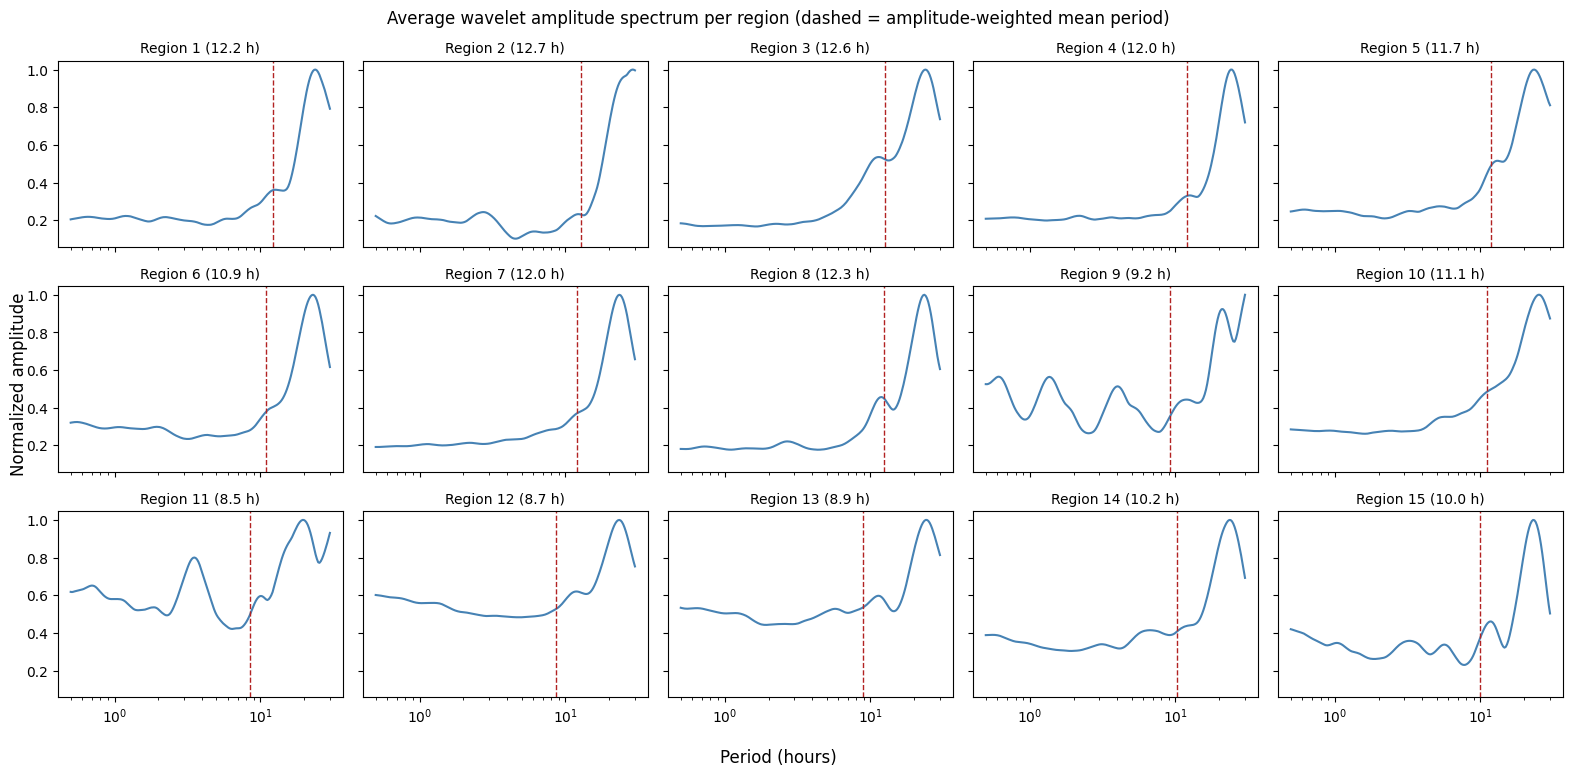

In [14]:
# One small panel per region: its average (mode-summed) wavelet amplitude spectrum, with a
# dashed line marking the amplitude-weighted mean period -- i.e. where that curve's mass is
# centered, this region's "most meaningful timeframe".
region_ids_wav = sorted(average_spectrum.keys())
ncols = 5
nrows = int(np.ceil(len(region_ids_wav) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2 * ncols, 2.6 * nrows), sharex=True, sharey=True)
axes_flat = np.atleast_1d(axes).flatten()

for ax, rid in zip(axes_flat, region_ids_wav):
    spectrum = average_spectrum[rid]
    ax.plot(period_hours, spectrum / spectrum.max(), color="steelblue", linewidth=1.5)
    ax.axvline(region_period_hours[rid], color="firebrick", linestyle="--", linewidth=1)
    ax.set_xscale("log")
    ax.set_title(f"Region {rid} ({region_period_hours[rid]:.1f} h)", fontsize=10)

for ax in axes_flat[len(region_ids_wav):]:
    ax.axis("off")

fig.supxlabel("Period (hours)")
fig.supylabel("Normalized amplitude")
fig.suptitle("Average wavelet amplitude spectrum per region (dashed = amplitude-weighted mean period)")
plt.tight_layout()
plt.show()

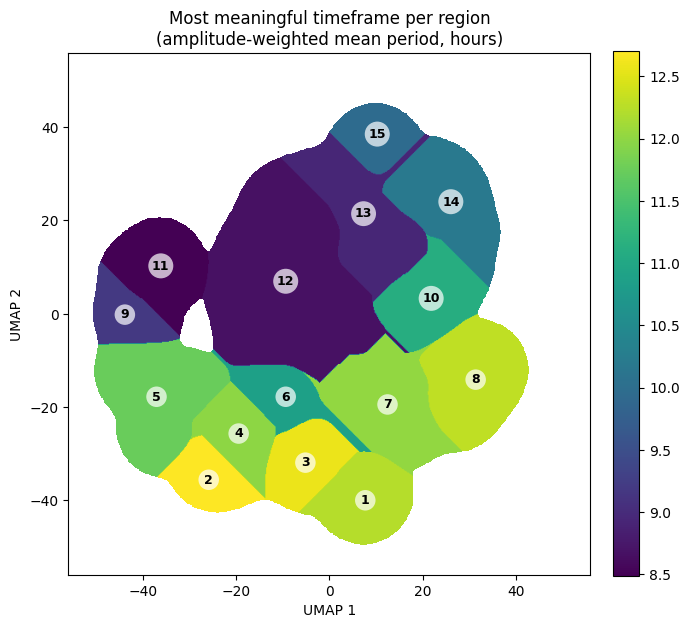

In [15]:
fig, ax = plt.subplots(figsize=(7, 7))
plot_region_heatmap(
    ax, LL, region_period_hours, xx, wbounds,
    "Most meaningful timeframe per region\n(amplitude-weighted mean period, hours)",
    "viridis",
)
plt.tight_layout()
plt.show()